# DOES HIGHER GDP MEAN HIGHER LIFE EXPECTANCY
## 1. INTRODUCTION
This analysis was carried out using a Life expectancy csv dataset downloaded from kaggle. The aim of this analysis is to determine whether GDP determines the life expecancy of a country, therefore only the applicable columns from the dataset were used. The countries within the dataset are grouped according to development status to make the data more comprehensible. The sample size was also further narrowed down to a focus of developmental status in the year 2015.

 The analysis will be carried out in the following steps by answering the following research questions:

1. What is the estimated average life expectancy across all countries, and how precisely can we estimate 
it?

2. Does life expectancy vary based on development status?

3. Do developed countries have a higher GDP than developing countries.

then finally,

4.	Does GDP per capita predict life expectancy? 

In [61]:
# noqa
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt


In [62]:
df= pd.read_csv(r"C:\Users\User\Downloads\Life Expectancy Data.csv")
df.columns = df.columns.str.strip()

In [63]:
df.describe()
df.info() #acquiring info about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [64]:
df.isnull().sum() #checking for empty cells


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

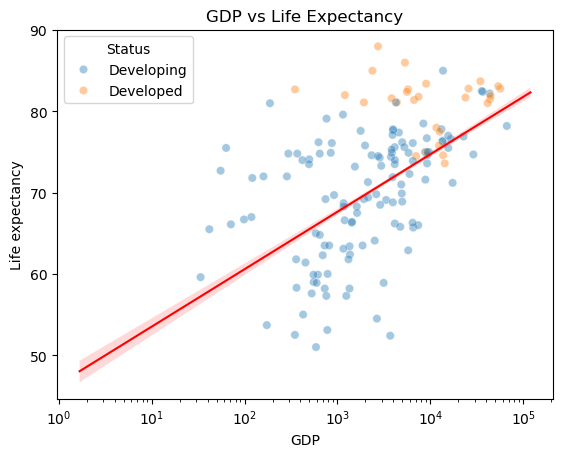

In [65]:
df_2015 = df[df['Year'] == 2015]
sns.scatterplot(data=df_2015, x='GDP', y='Life expectancy', hue='Status', alpha=0.4)
plt.title('GDP vs Life Expectancy')
plt.xscale('log')
plt.xlabel('GDP per Capita')
plt.ylabel(' Life Expectancy ')
sns.regplot(data=df, x='GDP', y='Life expectancy', 
            scatter=False, logx=True, color='red', line_kws={'linewidth': 1.5})
plt.show()

CHART B:


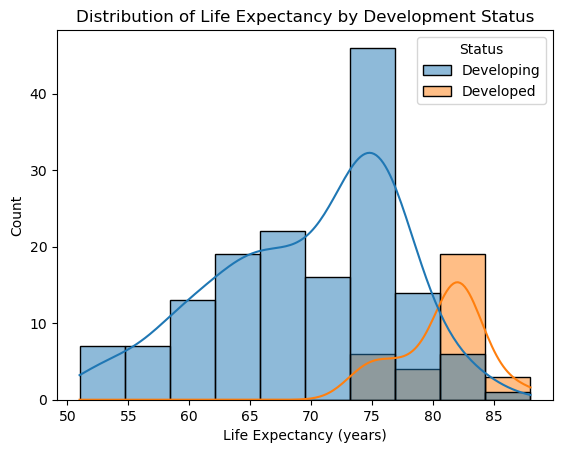

In [66]:
df_2015 = df[df['Year'] == 2015]

print("CHART B:")
sns.histplot(data=df_2015, x='Life expectancy', hue='Status', kde=True)
plt.title('Distribution of Life Expectancy by Development Status')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Count')
plt.show()

In [67]:

#---Calculating the averages that will be used in questions 1 & 2---

# #lets get the averages of the life expectancy by status, then by overall year(2015)
#start by filtering to the year 2015
df_2015 = df[df['Year'] == 2015]

#next, lets get the average life expectancy for developed countries only
df_developed = df[(df['Status'] == 'Developed') & (df['Year'] == 2015) ]
developed_expectancy = df_developed['Life expectancy'].mean()
print(f"the average life expectancy of all developed countries in 2015 is: {developed_expectancy:.2f}")

#now, the average life expectancy of developing countries
df_developing = df[(df['Status'] == 'Developing') & (df['Year'] == 2015)]
developing_expectancy = df_developing['Life expectancy'].mean()
print(f"The average life expectancy for developing countries is: {developing_expectancy:.2f}")

#overall life expectancy
average_life_expectancy = df_2015['Life expectancy'].mean()
print(f"The average life expectancy of all countries in 2015 is: {average_life_expectancy:.2f} years")
#print(df_2015['Life expectancy'].describe())

#finally, a comparison
if developed_expectancy > developing_expectancy:
 print("the average life expectancy of developed countries is greater than that of developing countries")

the average life expectancy of all developed countries in 2015 is: 80.71
The average life expectancy for developing countries is: 69.69
The average life expectancy of all countries in 2015 is: 71.62 years
the average life expectancy of developed countries is greater than that of developing countries


# QUESTION 1: What is the estimated average life expectancy across all countries, and how precisely can we estimate it? 

In [68]:
#---Calculating the confidence interval of the life expectancy---

df_developed = df[(df['Status'] == 'Developed') & (df['Year'] == 2015) ]
df_developing = df[(df['Status'] == 'Developing') & (df['Year'] == 2015)]

#---Calculating the confidence using the stats library---
#---I used a confidence level of 95%(sweet spot)---

confidence_developed = 0.95
dof_developed = len(df_developed)- 1
loc_developed = developed_expectancy
scale_developed = stats.sem(df_developed['Life expectancy'])

ci_developed = stats.t.interval(confidence_developed, dof_developed, loc_developed, scale_developed)

confidence_developing = 0.95
dof_developing = len(df_developing)- 1
loc_developing = developing_expectancy
scale_developing = stats.sem(df_developing['Life expectancy'])

ci_developing = stats.t.interval(confidence_developing, dof_developing, loc_developing, scale_developing)

print("The confidence interval of the life expectancy of developed and developing countries:")
print(f"Developed countries: 95% CI = ({ci_developed[0]:.2f}, {ci_developed[1]:.2f})")
print(f"Developing countries: 95% CI = ({ci_developing[0]:.2f}, {ci_developing[1]:.2f})")

The confidence interval of the life expectancy of developed and developing countries:
Developed countries: 95% CI = (79.46, 81.96)
Developing countries: 95% CI = (68.48, 70.90)


**Q1 CONCLUSION**

From the above results, we can conclude that the mean range of life expectancy in developed countries is higher than that of developing. Therefore, developed countries have a higher life expectancy.

# QUESTION 2: DOES LIFE EXPECTANCY VARY BASED ON DEVELOPMENT STATUS
Objective: Determine whether life expectancy varies with the development status of a country.

First, we will start by analysing the data displayed by the histogram chart (CHART B). The observation made were as follows:

The distribution of the histogram shows that developed countries (distinguished by orange) have a higher life expectancy than the developing countries.

However, is this claim purely coincidental or factual?

To test the credability of this claim, I constructed two possible hypotheses as follows that will be used to conduct the t-test:

null = Mean of life expectancy of developed and developing countries are equal.

alternative = Mean of life expectancy of developed and developing countries are not equal.


In [69]:
#---conducting a t-test to determine whether the difference is significant---

t_stat, p_value = stats.ttest_ind(df_developed['Life expectancy'], 
                                   df_developing['Life expectancy'])

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2f}")

if p_value < 0.05:
    print("Conclusion: The difference is statistically significant. Null hypothesis rejected.")
else:
    print("Conclusion: The results are purely coincidental. The null hypothesis is sustained.")

T-statistic: 8.12
P-value: 0.00
Conclusion: The difference is statistically significant. Null hypothesis rejected.


**Q2 CONCLUSION**

From the above results we can conclude that there is a significant difference between the life expectancy of developed and developing countries, and that developed countries have a higher life expectancy than those that are still developing. These variations reflect the reality that healthcare infrastructure, economic stability, environmental factors, and social factors are determinants of health (The Global Statistics, 2025). Developed countries generally have better health infrastructure and policies which provides them with higher healthcare quality. This means that residents of developed countries have better access to life saving healthcare which contributes to the longevity of their lives. Furthermore, developed countries have more economic stability than developing ones. Due to this, residents can afford life saving treatment and medication thereby giving them a greater chance to live longer.

# QUESTION 3: Do developed countries have a higher GDP than developing countries. 

From the previous research questions, we have already proven that developed countries have a higher life expectancy than developing. However, the original basis of this whole analysis is to determine whether countries with a higher GDP also have high life expectancies. Therefore, we will try to prove the relationship between GDP and development status to further strengthen our arguement.

To do that, we will carry out a t-test to prove the following hypotheses:

Null = The GDP of both developed and developing countries are equal

Alternative = The GDP of deveolped countries is higher than developing countries

In [70]:
#---Calculating the averages that will be used in questions 1 & 2---

# #lets get the averages of the life expectancy by status, then by overall year(2015)
#start by filtering to the year 2015
df_2015 = df[df['Year'] == 2015]

#next, lets get the average life expectancy for developed countries only
df_developed = df[(df['Status'] == 'Developed') & (df['Year'] == 2015)]
developed_gdp = df_developed['GDP'].mean()
print(f"the average GDP of all developed countries in 2015 is: {developed_gdp:.2f}")

#now, the average life expectancy of developing countries
df_developing = df[(df['Status'] == 'Developing') & (df['Year'] == 2015)]
developing_gdp = df_developing['GDP'].mean()
print(f"The average GDP for developing countries is: {developing_gdp:.2f}")

#overall life expectancy
average_gdp= df_2015['GDP'].mean()
print(f"The average GDP of all countries in 2015 is: {average_gdp:.2f}")
#print(df_2015['Life expectancy'].describe())

#finally, a comparison
if developed_expectancy > developing_expectancy:
    print("the average gdp of developed countries is greater than that of developing countries")


the average GDP of all developed countries in 2015 is: 16434.96
The average GDP for developing countries is: 5129.86
The average GDP of all countries in 2015 is: 7185.33
the average gdp of developed countries is greater than that of developing countries


In [71]:
#---conducting a t-test to determine whether the difference is significant---

t_stat1, p_value1 = stats.ttest_ind(df_developed['GDP'].dropna(), 
                                   df_developing['GDP'].dropna())

print(f"T-statistic: {t_stat1:.2f}")
print(f"P-value: {p_value1:.6f}")

if p_value1 < 0.05:
    print("Conclusion: The difference is statistically significant. Null hypothesis rejected.")
else:
    print("Conclusion: The results are purely coincidental. The null hypothesis is sustained.")

T-statistic: 4.97
P-value: 0.000002
Conclusion: The difference is statistically significant. Null hypothesis rejected.


**Q3 CONCLUSION**

From the above results, we can conclude that developed countries do indeed have a significantly higher GDP that developing countries. A relationship between GDP and development status is therefore established and we can now proceed with our analysis to prove that GDP determines life expectancy.

# QUESTION 4: Does GDP per Capita predict life expectancy.
Objective: Determine whether there is a **meaningful** relationship between GDP and life expectancy.

From the correlation graph (GRAPH A), we observe that there exists a positive relationship between the two variables. However, we need to determine the strength of this relationship and whether it is meaningful. To do this, we will carry out a correlation and simple linear regression analysis.



In [72]:

from scipy.stats import pearsonr
import statsmodels.api as sm

df_2015 = df[df['Year'] == 2015].dropna(subset=['GDP', 'Life expectancy'])

x = df_2015['GDP']
y = df_2015['Life expectancy']

result = pearsonr(x, y)

print(f"Pearson Correlation Coefficient: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

#calcculating the simple linear regression
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())


Pearson Correlation Coefficient: 0.4545
P-value: 0.0000
                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     39.57
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.20e-09
Time:                        15:34:26   Log-Likelihood:                -525.75
No. Observations:                 154   AIC:                             1055.
Df Residuals:                     152   BIC:                             1062.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

**Q.4 CONCLUSION:**

From the above data, we can conclude that a moderate positive relationship exists between GDP and life expectancy. This implies that although GDP is a factor that determines Life expectancy, it may not be the only one. Life expectancy is determined by a number of factors such as lifestyle, genetics, socioeconomic, and environmental factors (Teahan, 2023). 


# Implications of the results on the real-world

These finding carry several real-world implications. Longevity has major effects on careers and the workforce, such that people from developed countries tend to have longer careers. This is due to the fact that governments raise the legal retirement age as a response to higher life expectancy. Countries such as Denmark, Iceland, the Netherlands, and Norway have the highest current retirement ages, which currently sits at 67 years while Turkiye sits at 57(Statista, 2026). The legal retirement age is further expected to rise with the increase in life expectancy, as life expectancy is expected to rise steadily in most of the world, with a few variations in countries, through 2050 (ScienceInsights, 2026).

This could see countries raising their current legal retirement ages in the future, including developing countries. In fact, Denmark has already moved to increase its retirement age to 70 years, effective from 2040 (Financialexpress.com, 2025).

From a business perspective, higher life expectancy creates opportunities for business marketers due to the existence of an older demographic. This is known as the silver economy, which refers to the system of production, distribution and consumption of goods and services designed for older people, using their growing purchasing power and experience (Team, 2026). Sectors such as healthcare, insurance, housing and transportation are well positioned to take advantage of this opportunity and are set to greatly benefit.



# CONCLUSION

Our findings show that development status of a country reflects its average life expectancy, and that developed countries have a life expectancy than developing countries. Factors such as healthcare infrastructure, economic stability, socioeconomic and environmental factors play a major role in determining life expectancy. Generally, developed countries tend to have better healthcare infrastructure and economic stability.

Furthermore, we find that developed countries have a higher GDP than those with developing status. Thus, a clear relationship between GDP and life expectancy is established. However, the relationship is only moderate which suggests that other factors such as genetics, lifestyle, socioecononic factors and environmental factors also determine life expectancy. The findings of this research is significant in understanding the influence GDP has on life expectancy. 

Finally, the results of this analysis carries implications on businesses and how lives are impacted that are important to highlight. The legal retirement age follows the average life expectancy of a country, as countries in which it is high have a higher legal retirement age. With the life expectancy age expected to rise between now and 2050, some countries such as Denmark are already preparing to futher raise the retirement age in response to this. Furthermore, higher life expectancies create opportunities for businesses to take advantage of the existence of a silver economy.



# REFERENCES

Teahan, M. (2023). Human Lifespan: Understanding the Dynamics of Longevity. [online] Spencer Institute Health, Holistic and Wellness Certifications. Available at: https://spencerinstitute.com/human-lifespan-understanding-the-dynamics-of-longevity/.

‌The Global Statistics. (2025). Life Expectancy by Country 2025 | Stats & Facts. [online] Available at: https://www.theglobalstatistics.com/life-expectancy-by-country/#google_vignette.

Statista. (2026). Retirement age worldwide by country| Statista. [online] Available at: https://www.statista.com/statistics/268824/retirement-age-in-international-comparison [Accessed 5 May 2026].

‌Financialexpress.com. (2025). The Financial Express. [online] Available at: https://www.financialexpress.com/business/investing-abroad-denmark-retirement-age-increased-to-70-how-much-extra-pension-can-danish-citizens-expect-3865332/ [Accessed 5 May 2026].

Team, V.C. (2026). Silver Economy, Features, Significance, Challenges, Initiatives. [online] User’s blog. Available at: https://vajiramandravi.com/current-affairs/silver-economy/ [Accessed 5 May 2026].‌